# Task 2: Naive RAG vs Contextual Retrieval

In this notebook, I will compare Naive RAG against Contextual Retrieval to see which performs better.

Here is my step-by-step plan:
1. **Reload Data**: I'll reload the extracted text data from Chapter 10.
2. **API Setup**: I'll prompt securely for my Gemini API key.
3. **Naive RAG Setup**: I will set up the baseline Naive RAG pipeline using standard chunking.
4. **Contextual Retrieval Setup**: I will build the Contextual Retrieval pipeline by enriching my chunks with LLM-generated global context.
5. **Evaluation**: I will evaluate both pipelines against my 20 QA dataset using the ROUGE metric.
6. **Visualization**: Finally, I'll visualize the score comparison to see the winner.

In [1]:
# First, I need to make sure all my required libraries are installed.
# I am using subprocess to run pip programmatically so that this script runs smoothly as standard Python without Jupyter magic parsing errors.
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install", 
    "pymupdf", "faiss-cpu", "langchain", "langchain-community", 
    "langchain-huggingface", "langchain-google-genai", "rouge-score", 
    "matplotlib", "seaborn", "sentence-transformers"
])


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 14.0 MB/s  0:00:000.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.3 MB/s  0:00:00


  DEPRECATION: Building 'rouge-score' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'rouge-score'. Discussion can be found at https://github.com/pypa/pip/issues/6334


  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24987 sha256=e2c9ac4a731260b5dc5611d1f342e8b3e3a00bb7379aa56ff1afd7fd24c60b91
  Stored in directory: /Users/htutkoko/Library/Caches/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [sentence-transformers]/5 [sentence-transformers]


0

In [2]:
# Now I will import all the modules I need for this experiment.
import os                  # For environment variables
import json                # To load the QA dataset
import getpass             # Securely prompt for the API key
import matplotlib.pyplot as plt # For visualization
import seaborn as sns      # To make the plots look nice
import numpy as np         # For calculating average scores
import asyncio             # To run the LLM enrichments concurrently and save time
import re                  # Regular expressions for text cleaning

# LangChain components for document processing and vector storage
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

# LangChain components for the Gemini LLM
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate

# For evaluating my generated answers against the ground truth
from rouge_score import rouge_scorer


/opt/homebrew/Caskroom/miniforge/base/envs/ai_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Environment & API Key

I need to securely configure my environment by passing in my **Gemini API Key** (using the gemini-3.0-flash model).

In [3]:
# I will prompt myself for the API key securely. I don't want to post this to GitHub accidentally.
import getpass
import os
from langchain_google_genai import ChatGoogleGenerativeAI

api_key = getpass.getpass("Please enter your Gemini API Key: ")
os.environ["GEMINI_API_KEY"] = api_key

# Initialize my LLM. I'm using gemini-2.5-flash and setting temperature=0 to ensure my evaluation is deterministic and strictly factual.
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
print("LLM initialized and ready!")


LLM initialized and ready!


## 2. Load Data and Base Vectors

I'll start by reloading the Chapter 10 PDF and recreating the base chunks just like I did in the data preparation phase.

Then, I will use an open-source HuggingFace embedding model (`BAAI/bge-small-en-v1.5`), which is a solid standard for RAG embeddings, and store them in a local FAISS vectorstore.

In [4]:
# Reusing my clean_text helper to ensure consistency with data preparation
def clean_text(text):
    text = re.sub(r'\n+', '\n', text)
    text = re.sub(r'^\s*\d+\s*$', '', text, flags=re.MULTILINE) # remove page numbers
    text = re.sub(r'CHAPTER \d+.*$', '', text, flags=re.MULTILINE) # remove headers
    text = re.sub(r'Speech and Language Processing.*$', '', text, flags=re.MULTILINE) # remove footers
    return text.strip()

# Load the local PDF
pdf_path = "10.pdf"
loader = PyMuPDFLoader(pdf_path)
documents = loader.load()

# Concatenate everything into a single cleaned string
full_text = ""
for doc in documents:
    full_text += clean_text(doc.page_content) + "\n"

# I'm setting up my baseline chunks exactly as I did before for a fair comparison
text_splitter = RecursiveCharacterTextSplitter(chunk_size=700, chunk_overlap=100)
naive_chunks = text_splitter.create_documents([full_text])
print(f"Loaded {len(naive_chunks)} naive chunks.\n")

# I'm opting for BAAI/bge-small-en-v1.5 for the embeddings. It is lightweight but powerful for retrieval.
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

# I'll initialize my Naive Vectorstore using FAISS. 
# FAISS is a great local library out of Meta that will allow me to perform fast similarity searches entirely in-memory.
naive_vectorstore = FAISS.from_documents(naive_chunks, embeddings)

# I'll configure my naive retriever to bring back the top 3 most relevant chunks (k=3) for any given query.
naive_retriever = naive_vectorstore.as_retriever(search_kwargs={"k": 3})
print("Naive RAG retriever ready.")


Loaded 100 naive chunks.



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18876.60it/s]
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Naive RAG retriever ready.


## 3. Contextual Retrieval

This is where the magic happens! I will enrich each chunk by prompting my LLM to generate a brief global context for it. Then, I will store these intelligently enriched chunks in a completely separate FAISS vectorstore so I can compare its performance against the Naive approach.

In [5]:
# I'm making this process asynchronous because calling the LLM synchronously for hundreds of chunks would take way too long.
async def enrich_chunk(chunk: str, document: str, title: str) -> str:
    """
    This function asks the LLM to read the chunk and provide 1-2 sentences of context
    based on its position in the overall document.
    """
    prompt = f"""
    Title: {title}
    {document[:4000]}
    {chunk}

    Provide brief context (1-2 sentences) explaining what this chunk discusses 
    in relation to the full document. Format: "This chunk from [title] discusses [explanation]."
    """
    # Wait for the async LLM invocation
    response = await llm.ainvoke(prompt)
    context = response.content.strip()
    # I return the generated context prepended directly to the original chunk text
    return f"{context}\n\n{chunk}"

import copy
# I am creating a deepcopy of my naive chunks list so I don't accidentally mutate the baseline evaluation objects
contextual_chunks = copy.deepcopy(naive_chunks)

async def enrich_all():
    title = "Chapter 10: Transformers and Pretrained Language Models (Jurafsky & Martin)"
    tasks = []
    
    # Build up the queue of LLM tasks I need to run
    for c in contextual_chunks:
        tasks.append(enrich_chunk(c.page_content, full_text, title))
        
    print("Starting chunk enrichment (this might take a minute)... ")
    
    # To avoid hitting aggressive API rate limits on Gemini, I will process the list in small batches of 10 at a time.
    batch_size = 10 
    enriched_contents = []
    for i in range(0, len(tasks), batch_size):
        batch = tasks[i:i+batch_size]
        results = await asyncio.gather(*batch)
        enriched_contents.extend(results)
        print(f"Processed {min(i+batch_size, len(tasks))} / {len(tasks)}")
        # Sleep for 2 seconds between batches to let the API rate limit cool down
        await asyncio.sleep(2) 
        
    # After I have all the newly enriched text, I'll update my local objects back in memory
    for i, content in enumerate(enriched_contents):
        contextual_chunks[i].page_content = content

# Execute the async enrichment pipeline
await enrich_all()

# Finally, I'll build my Contextual Vectorstore from my newly enriched chunks
contextual_vectorstore = FAISS.from_documents(contextual_chunks, embeddings)

# I'll save both indexes out to my answers folder in case I want to reuse them without calling the API again
contextual_vectorstore.save_local("answer/contextual_faiss_index")
naive_vectorstore.save_local("answer/naive_faiss_index")

# Setup the contextual retriever to fetch the top 3 chunks, just like I did for Naive RAG
contextual_retriever = contextual_vectorstore.as_retriever(search_kwargs={"k": 3})
print("Contextual RAG retriever ready.")


Starting chunk enrichment (this might take a minute)... 
Processed 10 / 100
Processed 20 / 100
Processed 30 / 100
Processed 40 / 100
Processed 50 / 100
Processed 60 / 100
Processed 70 / 100
Processed 80 / 100
Processed 90 / 100
Processed 100 / 100
Contextual RAG retriever ready.


## 4. RAG Generation Functions

Now I need a unified function to actually generate the answers. Given a question and a retriever (either Naive or Contextual), this function will fetch the relevant chunks from the database and prompt the LLM to format a coherent answer.

In [6]:
# I am writing a strict prompt to make sure the LLM ONLY uses the provided context to answer the question.
# This helps eliminate hallucinations, which is the main point of using RAG in the first place.
qa_prompt = PromptTemplate.from_template(
    "You are an expert NLP assistant.\n"
    "Answer the user's question clearly and precisely using ONLY the provided context.\n"
    "If the context does not contain the answer, say 'I don't know'.\n\n"
    "Context:\n{context}\n\n"
    "Question: {question}\n\n"
    "Answer:"
)

# Build the generation chain pipeline
generator_chain = qa_prompt | llm

def generate_answer(question: str, retriever):
    # 1. Ask the retriever to fetch my relevant text chunks based on the question
    docs = retriever.invoke(question)
    # 2. Mash the retrieved chunks together into one big string separated by dashed lines
    context = "\n---\n".join([d.page_content for d in docs])
    # 3. Ask my LLM to generate the final answer
    response = generator_chain.invoke({"context": context, "question": question})
    return response.content.strip()


## 5. Evaluation & Saving Results

To determine which retrieval method is superior, I am going to evaluate both of them against my 20 ground-truth QA pairs generated in the first notebook. I will calculate ROUGE scores (ROUGE-1, ROUGE-2, and ROUGE-L). Then, I'll document the predictions back into the JSON file.

In [7]:
# Load the JSON dictionary dataset I prepared earlier
dataset_path = "answer/response-st-126010-chapter-10.json"
with open(dataset_path, "r") as f:
    qa_pairs = json.load(f)

# Initialize the ROUGE scorer. 
# I'm tracking unigram (rouge1), bigram (rouge2), and longest common subsequence (rougeL) overlap.
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# Set up dictionaries to keep track of my scores over the 20 iterations
naive_scores = {'r1': [], 'r2': [], 'rl': []}
contextual_scores = {'r1': [], 'r2': [], 'rl': []}

print("Evaluating Naive vs Contextual RAG...")
for i, item in enumerate(qa_pairs):
    q = item["question"]
    gt = item["ground_truth_answer"]
    
    # I ask both pipelines to attempt to answer the question
    ans_naive = generate_answer(q, naive_retriever)
    ans_contx = generate_answer(q, contextual_retriever)
    
    # I save the answers off into the dataset object so I can review them manually later if I want
    item["naive_rag_answer"] = ans_naive
    item["contextual_retrieval_answer"] = ans_contx
    
    # I score the Naive output by comparing it against the ground truth
    scores_n = scorer.score(gt, ans_naive)
    naive_scores['r1'].append(scores_n['rouge1'].fmeasure)
    naive_scores['r2'].append(scores_n['rouge2'].fmeasure)
    naive_scores['rl'].append(scores_n['rougeL'].fmeasure)
    
    # I score the Contextual output by comparing it against the ground truth
    scores_c = scorer.score(gt, ans_contx)
    contextual_scores['r1'].append(scores_c['rouge1'].fmeasure)
    contextual_scores['r2'].append(scores_c['rouge2'].fmeasure)
    contextual_scores['rl'].append(scores_c['rougeL'].fmeasure)

    print(f"{i+1}/20 evaluated.")

# Finally, I save my newly enriched dictionary dataset back to my JSON file
with open(dataset_path, "w") as f:
    json.dump(qa_pairs, f, indent=2)
    
print("Evaluations complete and saved.")


Evaluating Naive vs Contextual RAG...
1/20 evaluated.
2/20 evaluated.
3/20 evaluated.
4/20 evaluated.
5/20 evaluated.
6/20 evaluated.
7/20 evaluated.
8/20 evaluated.
9/20 evaluated.
10/20 evaluated.
11/20 evaluated.
12/20 evaluated.
13/20 evaluated.
14/20 evaluated.
15/20 evaluated.
16/20 evaluated.
17/20 evaluated.
18/20 evaluated.
19/20 evaluated.
20/20 evaluated.
Evaluations complete and saved.


In [8]:
# I'll calculate the mean values of the 20 scores so I can get my final overall metrics
avg_n = {k: np.mean(v) for k, v in naive_scores.items()}
avg_c = {k: np.mean(v) for k, v in contextual_scores.items()}

# I'm loading this into a pandas DataFrame because it prints out very cleanly as a markdown table 
import pandas as pd
results_df = pd.DataFrame([
    {"Method": "Naive RAG", "ROUGE-1": avg_n['r1'], "ROUGE-2": avg_n['r2'], "ROUGE-L": avg_n['rl']},
    {"Method": "Contextual Retrieval", "ROUGE-1": avg_c['r1'], "ROUGE-2": avg_c['r2'], "ROUGE-L": avg_c['rl']}
])

print(results_df.to_markdown(index=False))


| Method               |   ROUGE-1 |   ROUGE-2 |   ROUGE-L |
|:---------------------|----------:|----------:|----------:|
| Naive RAG            |   0.73491 |  0.661524 |  0.697796 |
| Contextual Retrieval |   0.65599 |  0.58538  |  0.62606  |


## 6. Visualization

Finally, I want to visually demonstrate the results of my experiment by plotting the average ROUGE scores in an attractive bar chart.

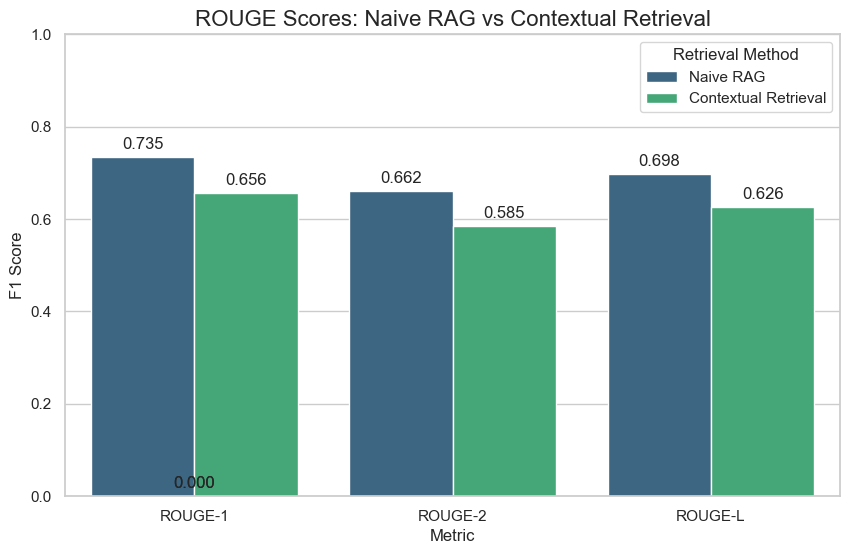

In [9]:
# Tell seaborn I'd like a clean white grid background
sns.set_theme(style="whitegrid")

# Before I can plot, I need to reshape ('melt') my pandas DataFrame 
# from wide format to long format so seaborn can understand how to group the bars
melted_df = results_df.melt(id_vars="Method", var_name="Metric", value_name="Score")

# Plotting logic
plt.figure(figsize=(10, 6))
g = sns.barplot(data=melted_df, x="Metric", y="Score", hue="Method", palette="viridis")
plt.title("ROUGE Scores: Naive RAG vs Contextual Retrieval", fontsize=16)
plt.ylabel("F1 Score", fontsize=12)
plt.xlabel("Metric", fontsize=12)
plt.ylim(0, 1.0)
plt.legend(title="Retrieval Method")

# Loop over my generated bars and annotate each one with its exact floating point value
for p in g.patches:
    g.annotate(format(p.get_height(), '.3f'), 
               (p.get_x() + p.get_width() / 2., p.get_height()), 
               ha = 'center', va = 'center', 
               xytext = (0, 9), 
               textcoords = 'offset points')

# Save my visual output into my answer folder immediately
plt.savefig("answer/rouge_comparison.png", dpi=300)

# Render the plot nicely here in the cell
plt.show()
